<a href="https://colab.research.google.com/github/visionbyangelic/Neuromatch/blob/main/comp-neuro/project-algonaut/Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing data



In [ ]:
import glob
hits = glob.glob('/content/drive/MyDrive/**/fmri', recursive=True)
print(hits)

['/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri', '/content/drive/MyDrive/Neuromatch/Algonauts/algonauts_2025.competitors/fmri']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

roots = [
    '/content/drive/MyDrive/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors',
    '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors',
    '/content/drive/MyDrive/Algonauts/algonauts_2025.competitors',
    '/content/drive/MyDrive/neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors'
]

for R in roots:
    print('=' * 70)
    print(R)
    n_files, total = 0, 0
    try:
        # os.walk will yield nothing if R doesn't exist, which is fine for n_files and total
        for dirpath, _, filenames in os.walk(R):
            for f in filenames:
                n_files += 1
                total += os.path.getsize(os.path.join(dirpath, f))
        print(f'{n_files} files, {total/1e9:.2f} GB')
        print('top level:', sorted(os.listdir(R)))
    except FileNotFoundError:
        print(f"Warning: Path not found for {R}. Skipping this root.")
    except Exception as e: # Catch other potential errors
        print(f"An unexpected error occurred for path {R}: {e}. Skipping this root.")

/content/drive/MyDrive/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors
0 files, 0.00 GB
/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors
22 files, 3.00 GB
top level: ['fmri', 'stimuli']
/content/drive/MyDrive/Algonauts/algonauts_2025.competitors
0 files, 0.00 GB
/content/drive/MyDrive/neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors
0 files, 0.00 GB


### Inspecting data

In [ ]:
import os

# Iterate through the roots to find an existing one
found_root = None
for r_path in roots:
    if os.path.exists(r_path):
        found_root = r_path
        break

if found_root:
    ROOT = found_root
    print(f"Using ROOT: {ROOT}")
    for dirpath, dirnames, filenames in os.walk(ROOT):
        depth = dirpath.replace(ROOT, '').count('/')
        print('  ' * depth, os.path.basename(dirpath) + '/')
        for f in sorted(filenames):
            size = os.path.getsize(os.path.join(dirpath, f)) / 1e6
            print('  ' * (depth + 1), f, f'({size:.1f} MB)')
elif roots:
    print(f"Warning: None of the specified root paths exist. Please check the 'roots' variable and ensure the data is mounted correctly. Attempted paths: {roots}")
    # You can choose to raise an error here if you want to stop execution explicitly
    # raise FileNotFoundError(f"None of the specified root paths exist: {roots}")
else:
    print("Warning: The 'roots' list is empty. Please define the paths to your data.")

Using ROOT: /content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors
 algonauts_2025.competitors/
   fmri/
     sub-05/
       func/
         sub-05_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5 (509.8 MB)
         sub-05_task-movie10_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_bold.h5 (92.2 MB)
       atlas/
         sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz (0.1 MB)
       target_sample_number/
         sub-05_friends-s7_fmri_samples.npy (0.0 MB)
         sub-05_ood_fmri_samples.npy (0.0 MB)
     sub-02/
       func/
         sub-02_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5 (514.9 MB)
         sub-02_task-movie10_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_bold.h5 (92.3 MB)
       atlas/
         sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_pa

In [ ]:
import os
SF = '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/stimulus_features'
assert os.path.exists(SF), SF

for dirpath, dirnames, filenames in os.walk(SF):
    print(dirpath.replace(SF, ''), '→', len(filenames), 'files')
    for f in sorted(filenames)[:5]:
        print('   ', f, f'({os.path.getsize(os.path.join(dirpath,f))/1e6:.1f} MB)')

 → 0 files
/raw → 0 files
/raw/visual → 1 files
    friends_s01e01a_features_visual.h5 (19.4 MB)
/raw/audio → 1 files
    friends_s01e01a_features_audio.h5 (0.0 MB)
/raw/language → 1 files
    friends_s01e01a_features_language.h5 (20.0 MB)
/pca → 0 files
/pca/friends_movie10 → 0 files
/pca/friends_movie10/visual → 2 files
    features_test.npy (23.5 MB)
    features_train.npy (155.6 MB)
/pca/friends_movie10/language → 2 files
    features_test.npy (23.5 MB)
    features_train.npy (155.6 MB)
/pca/friends_movie10/audio → 2 files
    features_test.npy (1.9 MB)
    features_train.npy (12.5 MB)
/pca/ood → 0 files
/pca/ood/visual → 1 files
    features_ood.npy (4.9 MB)
/pca/ood/language → 1 files
    features_ood.npy (4.0 MB)
/pca/ood/audio → 1 files
    features_ood.npy (0.4 MB)
/pca/friends → 0 files
/pca/friends/audio → 1 files
    features_train.npy (11.0 MB)
/pca/friends/language → 1 files
    features_train.npy (137.7 MB)
/pca/friends/visual → 1 files
    features_train.npy (137.7 MB)


In [ ]:
import numpy as np

SF = '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/stimulus_features'
P = f'{SF}/pca/friends'  # Re-evaluate P using the corrected SF

for mod in ['visual', 'audio', 'language']:
    # Corrected loading: remove mmap_mode, add allow_pickle and .item()
    X_dict = np.load(f'{P}/{mod}/features_train.npy', allow_pickle=True).item()

    # Get the shape and dtype from the first episode's data within the dictionary
    if X_dict: # Check if dictionary is not empty
        first_episode_data = np.asarray(list(X_dict.values())[0])
        print(mod, first_episode_data.shape, first_episode_data.dtype)
    else:
        print(mod, "No data found for this modality.")

visual (591, 250) float32
audio (591, 20) float32
language (591, 250) float32


So in total, we have:
* visual features 591 x 250
* audio features 591 x 20
* language features 591 x 250

* and they predict fMRI BOLD signal 591 x 1000 parcels, Schaefer 2018 atlas
* we got 282 clean espisodes and 4 subjects (01,02,03,05)

In [ ]:
import numpy as np

P = f'{SF}/pca/friends'

X = np.load(f'{P}/visual/features_train.npy', allow_pickle=True)
print(type(X), X.shape, X.dtype)

d = X.item() if X.shape == () else X    # 0-d object array → unwrap to the dict
print(type(d))
print('n keys:', len(d))
print('first keys:', list(d)[:8])

k = list(d)[0]
print('one episode:', k, np.asarray(d[k]).shape)

<class 'numpy.ndarray'> () object
<class 'dict'>
n keys: 292
first keys: ['s01e01a', 's01e01b', 's01e02a', 's01e02b', 's01e03a', 's01e03b', 's01e04a', 's01e04b']
one episode: s01e01a (591, 250)


In [ ]:
for mod in ['visual', 'audio', 'language']:
    d = np.load(f'{P}/{mod}/features_train.npy', allow_pickle=True).item()
    total = sum(np.asarray(v).shape[0] for v in d.values())
    dim   = np.asarray(d[list(d)[0]]).shape[-1]
    print(f'{mod:9s} {len(d):4d} episodes   {total:7d} TRs   {dim:4d} dims')

visual     292 episodes    137687 TRs    250 dims
audio      292 episodes    137687 TRs     20 dims
language   292 episodes    137681 TRs    250 dims


⬆ we got ~137,000 TR's per subjects

In [ ]:
FMRI = f'{ROOT}/fmri'   # ROOT = .../algonauts_2025.competitors
import glob
func_path = glob.glob(f'{FMRI}/sub-03/func/*task-friends*.h5')[0]
print(func_path)

/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-03/func/sub-03_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5


* 292 episodes. Not one. Six seasons.
* 137,687 moments. You thought you had 591.
* Language is 6 rows short. 137687 − 137681 = 6

* Something's off in six places. (Found later.)
* Also: visual and language both get 250 numbers, audio only gets 20. Remember that — it matters later.

In [ ]:
import h5py, numpy as np
with h5py.File(func_path, 'r') as f:
    ykeys = set(f.keys())
    print('func episodes:', len(ykeys))
    common = sorted(set(d) & ykeys)
    print('shared:', len(common))
    print('X-only:', sorted(set(d) - ykeys)[:5])
    print('Y-only:', sorted(ykeys - set(d))[:5])
    for k in common[:5]:
        print(k, 'X:', np.asarray(d[k]).shape, ' Y:', f[k].shape)

func episodes: 290
shared: 0
X-only: ['s01e01a', 's01e01b', 's01e02a', 's01e02b', 's01e03a']
Y-only: ['ses-001_task-s01e02a', 'ses-001_task-s01e02b', 'ses-001_task-s01e03a', 'ses-001_task-s01e03b', 'ses-002_task-s01e04a']


In [ ]:
mods = {}
for mod in ['visual', 'audio', 'language']:
    mods[mod] = np.load(f'{P}/{mod}/features_train.npy', allow_pickle=True).item()

for k in mods['visual']:
    nv = np.asarray(mods['visual'][k]).shape[0]
    nl = np.asarray(mods['language'][k]).shape[0]
    if nv != nl:
        print(k, 'visual:', nv, 'language:', nl, 'diff:', nv - nl)

s01e03b visual: 472 language: 471 diff: 1
s02e20a visual: 449 language: 448 diff: 1
s03e04b visual: 473 language: 472 diff: 1
s03e17b visual: 453 language: 452 diff: 1
s05e23d visual: 488 language: 487 diff: 1
s06e23a visual: 486 language: 485 diff: 1


In [ ]:
seasons = sorted({k[:3] for k in mods['visual'].keys()})
print(seasons)
print(len(mods['visual']), 'episodes total')

['s01', 's02', 's03', 's04', 's05', 's06']
292 episodes total


In [ ]:
BAD = {'s01e03b','s02e20a','s03e04b','s03e17b','s05e23d','s06e23a'}
episodes = [k for k in mods['visual'] if k not in BAD]

In [ ]:
import re

with h5py.File(func_path, 'r') as f:
    ykeys = list(f.keys())

# 'ses-001_task-s01e02a'  ->  's01e02a'
def ep(k):
    m = re.search(r'task-(s\d{2}e\d{2}[a-z])$', k)
    return m.group(1) if m else None

y2x = {k: ep(k) for k in ykeys}
assert all(y2x.values()), [k for k, v in y2x.items() if v is None]   # loud if the regex misses

xkeys = set(mods['visual'])
shared = sorted(v for v in y2x.values() if v in xkeys)
print('shared:', len(shared))
print('in Y but not X:', sorted(set(y2x.values()) - xkeys))
print('in X but not Y:', sorted(xkeys - set(y2x.values())))

shared: 290
in Y but not X: []
in X but not Y: ['s05e20a', 's06e03a']


In [ ]:
x2y = {v: k for k, v in y2x.items()}
with h5py.File(func_path, 'r') as f:
    diffs = {}
    for e in shared:
        nx = np.asarray(mods['visual'][e]).shape[0]
        ny = f[x2y[e]].shape[0]
        if nx != ny:
            diffs[e] = (nx, ny)
    print('episodes where X != Y:', len(diffs))
    print(list(diffs.items())[:10])

episodes where X != Y: 222
[('s01e01a', (591, 592)), ('s01e01b', (590, 592)), ('s01e04a', (502, 503)), ('s01e04b', (502, 503)), ('s01e07a', (492, 493)), ('s01e07b', (492, 493)), ('s01e08a', (475, 476)), ('s01e08b', (475, 476)), ('s01e09a', (467, 468)), ('s01e09b', (467, 468))]


In [ ]:
from collections import Counter
print(Counter(ny - nx for nx, ny in diffs.values()))

Counter({1: 220, 2: 2})


In [ ]:
def get_xy(ep, f, delay=0):
    Xv = np.asarray(mods['visual'][ep])
    Xa = np.asarray(mods['audio'][ep])
    Xl = np.asarray(mods['language'][ep])
    Y  = f[x2y[ep]][:]
    n = min(len(Xv), len(Xa), len(Xl), len(Y))
    return Xv[:n], Xa[:n], Xl[:n], Y[:n]      # ← truncating from the END. An assumption. Verify it.

In [ ]:
print([(e, nx, ny) for e, (nx, ny) in diffs.items() if ny - nx == 2])

[('s01e01b', 590, 592), ('s04e23a', 503, 505)]


In [ ]:
BAD_TR   = {'s01e01b', 's04e23a'}                                    # off-by-2
BAD_LANG = {'s01e03b','s02e20a','s03e04b','s03e17b','s05e23d','s06e23a'}  # language short by 1
episodes = sorted(set(shared) - BAD_TR - BAD_LANG)
print(len(episodes), 'clean episodes')                                # ~282

282 clean episodes


# loading atlas

In [ ]:
!pip install nilearn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import glob
glob.glob('/content/drive/MyDrive/**/*.nii.gz', recursive=True)

['/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz',
 '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz',
 '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz',
 '/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz',
 '/content/drive/MyDrive/Neuromatch/Algonauts/algonauts_2025.competitors/fmri/sub-05/atlas/sub-05_space-MNI152NLin20

(97, 115, 97)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_1257/3880750851.py:8: UserWarning: Casting data from int32 to float32
  plotting.view_img(atlas)   # interactive — drag through it



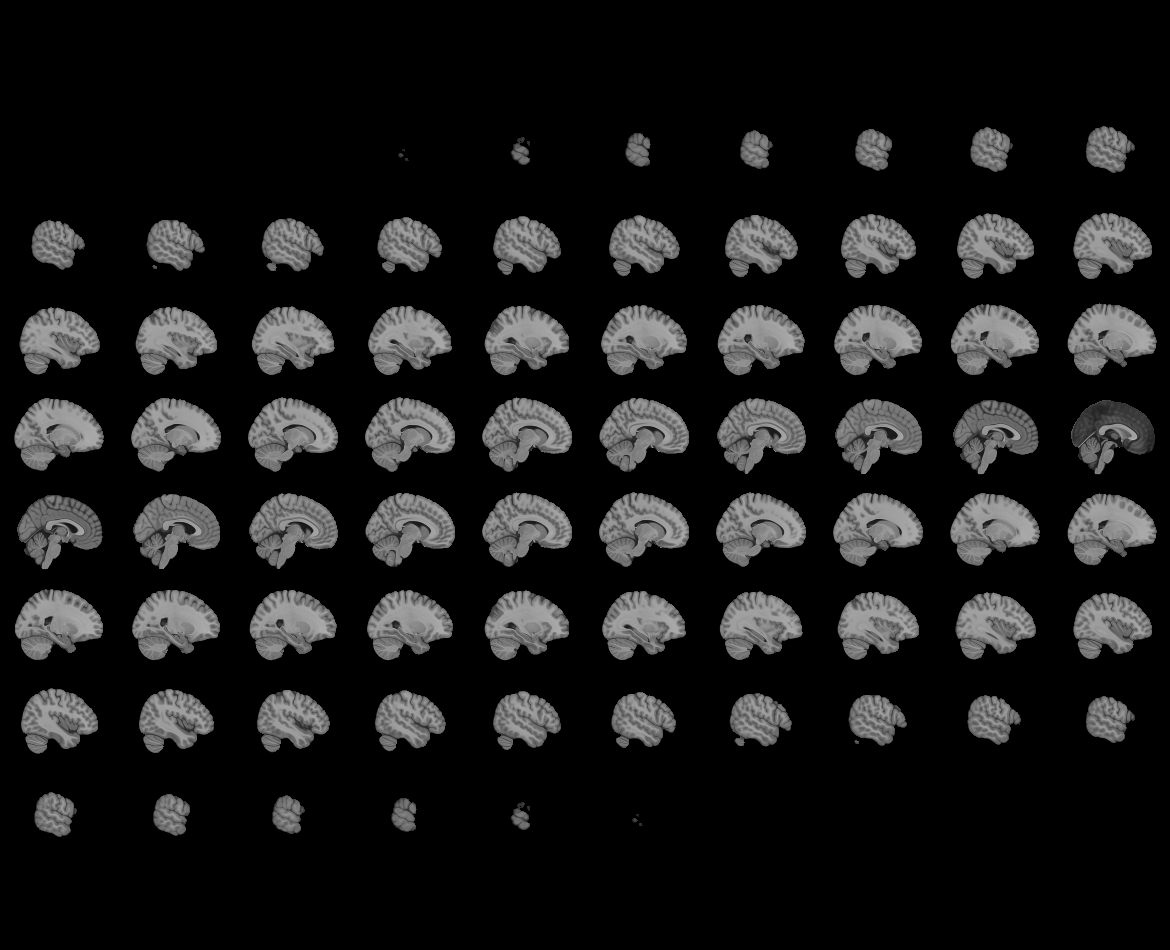
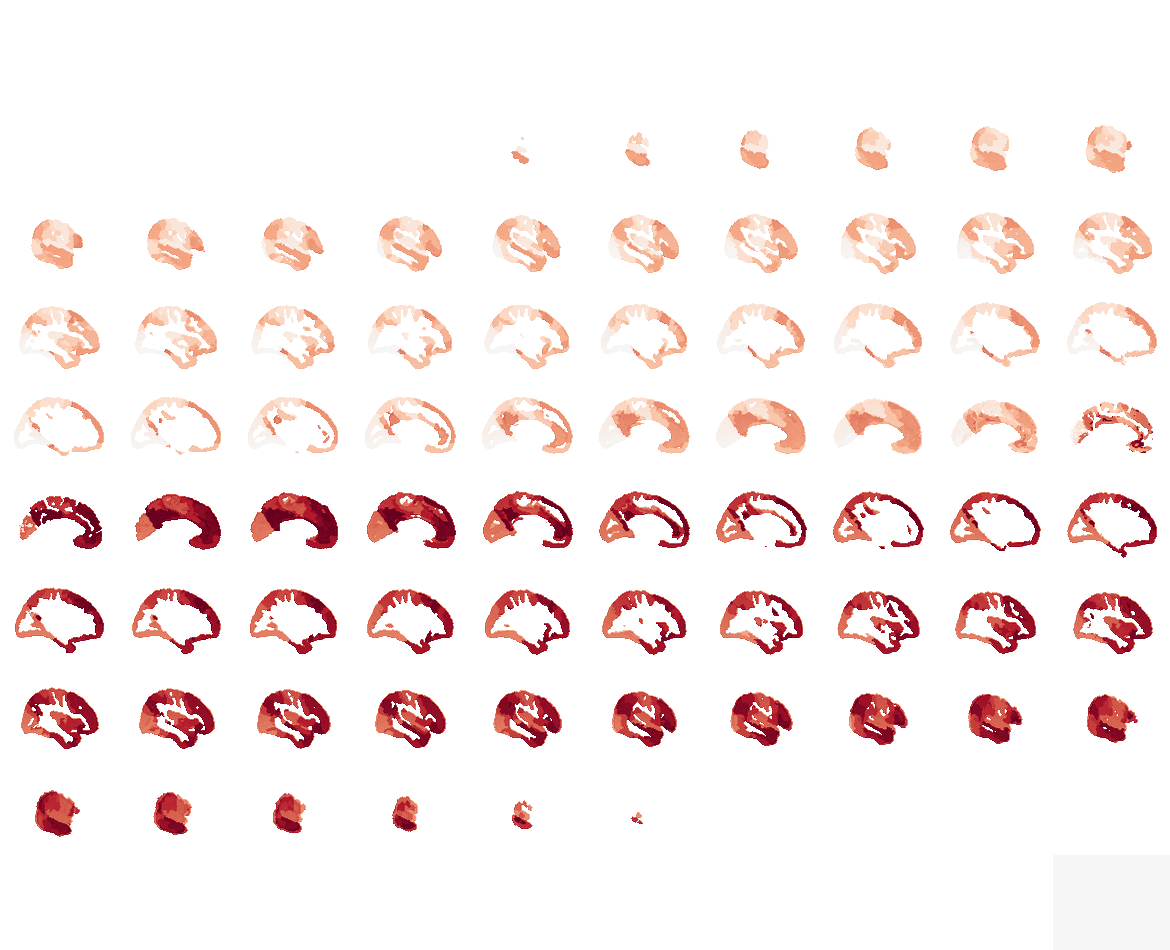

In [ ]:
from nilearn import plotting, image

atlas_path = '/content/drive/MyDrive/Neuromatch/Algonauts/algonauts_2025.competitors/fmri/sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz'

atlas = image.load_img(atlas_path)
print(atlas.shape)

plotting.view_img(atlas)   # interactive — drag through it

# brain ATLAS of subject 01

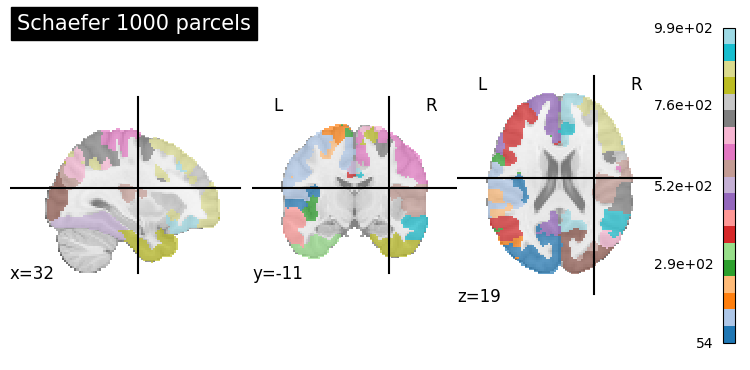

In [ ]:
plotting.plot_roi(atlas, title='Schaefer 1000 parcels', cmap='tab20')

⬆ think why Schaefer and not another one

In [ ]:
import numpy as np
from nilearn import image

base = '/content/drive/MyDrive/Neuromatch/Algonauts/algonauts_2025.competitors/fmri'
subs = ['sub-01', 'sub-02', 'sub-03', 'sub-05']

atlases = {}
for s in subs:
    p = f'{base}/{s}/atlas/{s}_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz'
    atlases[s] = image.load_img(p).get_fdata()
    print(s, atlases[s].shape, int(atlases[s].max()))

# are they the same?
print('01 == 02:', np.array_equal(atlases['sub-01'], atlases['sub-02']))
print('01 == 03:', np.array_equal(atlases['sub-01'], atlases['sub-03']))
print('01 == 05:', np.array_equal(atlases['sub-01'], atlases['sub-05']))

# atlases of all participants are identical - not need to check for each of them

sub-01 (97, 115, 97) 1000
sub-02 (97, 115, 97) 1000
sub-03 (97, 115, 97) 1000
sub-05 (97, 115, 97) 1000
01 == 02: True
01 == 03: True
01 == 05: True


In [ ]:
import os
base = '/content/drive/MyDrive/Neuromatch/Algonauts/algonauts_2025.competitors/fmri'
print(os.listdir(f'{base}/sub-01/atlas/'))

['sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz']


In [ ]:
from nilearn import datasets

schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=7, resolution_mm=2)

labels = list(schaefer.labels)
print(len(labels))
print(labels[:5])
print(labels[500:505])

[fetch_atlas_schaefer_2018] Dataset directory found: /root/nilearn_data/schaefer_2018

1001
['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']
['7Networks_LH_Default_PHC_3', '7Networks_RH_Vis_1', '7Networks_RH_Vis_2', '7Networks_RH_Vis_3', '7Networks_RH_Vis_4']


meaning of the output ⬆

```[fetch_atlas_schaefer_2018] Dataset directory found: /root/nilearn_data/schaefer_2018

1001
['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']
['7Networks_LH_Default_PHC_3', '7Networks_RH_Vis_1', '7Networks_RH_Vis_2', '7Networks_RH_Vis_3', '7Networks_RH_Vis_4']
```

`funct` data has 1000 columbs of numbers, column 417 is a brain region but we don't know which one. So we need labels/names of those areas to know which are language areas as it's of key importance for the study.

So why 1001 entries? It's off by 1. So 1000 columns do not line up with 1001 entries. 'Background' isn't a brain region - it's the 0's in the brain atlas volume (skull etc).

If we missed it then the whole parcel analysis would have been shifted by one. BAD.


In [ ]:
labels = list(schaefer.labels)[1:] # dropping the background
print(len(labels)) # must be 1000 and IT IS 1000

1000


In [ ]:
labels = list(schaefer.labels)[1:]

# what network exist, and who big is each?
from collections import Counter
nets = [l.split('_')[2] for l in labels]
print(Counter(nets))

# sample across the whole range
for i in range(0,1000,40):
  print(i,labels[i])

Counter({'Default': 212, 'SomMot': 194, 'Vis': 162, 'Cont': 129, 'DorsAttn': 122, 'SalVentAttn': 121, 'Limbic': 60})
0 7Networks_LH_Vis_1
40 7Networks_LH_Vis_41
80 7Networks_LH_Vis_81
120 7Networks_LH_SomMot_40
160 7Networks_LH_SomMot_80
200 7Networks_LH_DorsAttn_Post_29
240 7Networks_LH_SalVentAttn_ParOper_8
280 7Networks_LH_SalVentAttn_Med_12
320 7Networks_LH_Cont_Par_4
360 7Networks_LH_Cont_pCun_1
400 7Networks_LH_Default_Temp_8
440 7Networks_LH_Default_PFC_26
480 7Networks_LH_Default_pCunPCC_16
520 7Networks_RH_Vis_21
560 7Networks_RH_Vis_61
600 7Networks_RH_SomMot_20
640 7Networks_RH_SomMot_60
680 7Networks_RH_SomMot_100
720 7Networks_RH_DorsAttn_Post_37
760 7Networks_RH_SalVentAttn_TempOccPar_16
800 7Networks_RH_SalVentAttn_Med_10
840 7Networks_RH_Limbic_TempPole_16
880 7Networks_RH_Cont_PFCl_16
920 7Networks_RH_Default_Par_9
960 7Networks_RH_Default_PFCdPFCm_5


In [ ]:
subtags = sorted({'_'.join(l.split('_')[2:-1]) for l in labels})
for s in subtags:
    print(s)

Cont_Cing
Cont_OFC
Cont_PFCd
Cont_PFCl
Cont_PFCmp
Cont_PFCv
Cont_Par
Cont_Temp
Cont_pCun
Default_PFC
Default_PFCdPFCm
Default_PFCv
Default_PHC
Default_Par
Default_Temp
Default_pCunPCC
DorsAttn_FEF
DorsAttn_Post
DorsAttn_PrCv
Limbic_OFC
Limbic_TempPole
SalVentAttn_FrOperIns
SalVentAttn_Med
SalVentAttn_PFCl
SalVentAttn_ParOper
SalVentAttn_PrC
SalVentAttn_TempOcc
SalVentAttn_TempOccPar
SomMot
Vis


In [ ]:
sommot = [(i, l) for i, l in enumerate(labels) if 'SomMot' in l]

print(len(sommot), 'parcels')
for i, l in sommot[:15]:
    print(i, l)

194 parcels
81 7Networks_LH_SomMot_1
82 7Networks_LH_SomMot_2
83 7Networks_LH_SomMot_3
84 7Networks_LH_SomMot_4
85 7Networks_LH_SomMot_5
86 7Networks_LH_SomMot_6
87 7Networks_LH_SomMot_7
88 7Networks_LH_SomMot_8
89 7Networks_LH_SomMot_9
90 7Networks_LH_SomMot_10
91 7Networks_LH_SomMot_11
92 7Networks_LH_SomMot_12
93 7Networks_LH_SomMot_13
94 7Networks_LH_SomMot_14
95 7Networks_LH_SomMot_15


⬆ So: you cannot find auditory cortex by reading these names.

In [ ]:
default = sorted({l for l in labels if 'Default' in l and 'LH' in l})
print(len(default))
for l in default[:20]:
    print(l)

126
7Networks_LH_Default_PFC_1
7Networks_LH_Default_PFC_10
7Networks_LH_Default_PFC_11
7Networks_LH_Default_PFC_12
7Networks_LH_Default_PFC_13
7Networks_LH_Default_PFC_14
7Networks_LH_Default_PFC_15
7Networks_LH_Default_PFC_16
7Networks_LH_Default_PFC_17
7Networks_LH_Default_PFC_18
7Networks_LH_Default_PFC_19
7Networks_LH_Default_PFC_2
7Networks_LH_Default_PFC_20
7Networks_LH_Default_PFC_21
7Networks_LH_Default_PFC_22
7Networks_LH_Default_PFC_23
7Networks_LH_Default_PFC_24
7Networks_LH_Default_PFC_25
7Networks_LH_Default_PFC_26
7Networks_LH_Default_PFC_27


# NOTE — how do we decide *where* in the brain to look?

**Red NeuroTigers 🐯 — keep this, we'll need it in Week 3.**

## The problem

The Schaefer atlas has 7 networks: `Default`, `SomMot`, `Vis`, `Cont`, `DorsAttn`, `SalVentAttn`, `Limbic`.

**None of them is "Language."** We checked (cells below).

- `SomMot` (194 parcels) = touch + movement + **hearing**
- Its parcels are labelled only `SomMot_1 … SomMot_194` — no sub-names. So we can't even find auditory cortex by reading the labels.

**And we can't swap atlases.** The fMRI is *already* parcellated into 1000 columns. We don't have the raw voxels, so there's nothing left to re-parcellate.

→ So **we** have to decide which parcels count as "language." Two ways.

## The setup

After running both models (**with** words / **without** words), we get **1000 numbers** — one per parcel:

> *how much better did the model get when it was allowed to know the words?*

The whole question is what we do with those 1000 numbers.

---

## Option A — pick the parcels FIRST, then measure

1. Before running anything, declare: *"these ~40 parcels are the language area."*
2. Run the models.
3. Report the average improvement in those 40, vs. control parcels.

**Problem:** someone asks *"why those 40?"* — and we can't really defend it, because the atlas doesn't tell us. We'd be picking by educated guess. If the TA disagrees with our 40, the whole result is arguable.

---

## Option B — measure EVERYWHERE, then look ⭐ RECOMMENDED

1. Run the models on **all 1000 parcels**.
2. Paint the 1000 improvement numbers onto a brain image (nilearn does this).
3. **Look at where the dark patches are.**

If the biggest improvements land in **left frontal + left temporal** cortex — where language lives — that's the result.

We never picked anything, so nobody can accuse us of cherry-picking.

## ⚠️ Why B is safer — the trap it avoids

If we run the analysis, peek at the results, notice parcels 412 / 415 / 480 improved a lot, and *then* say **"those are our language parcels"** — we have **drawn the target around the arrow after it landed.**

That produces a beautiful "result" **even from pure random noise.**

It has a name: **circular analysis**. It's the classic way student projects fool themselves.

> **Option B makes this impossible. We can't cheat, because we never chose.**

---

## The one rule Option B still needs

We can't just stare at the map afterwards and tell whatever story fits.

**BEFORE running anything, write down what we expect:**

> *"If our hypothesis is right, the parcels with the biggest improvement will be in **left temporal and left frontal** cortex. Parcels in visual cortex and in SomMot (hearing) will barely improve."*

Then run it. Then look.

| What the map shows | What it means |
|---|---|
| Dark patches in left frontal + temporal | ✅ Hypothesis supported |
| Improvement spread evenly everywhere | ❌ We just gave the model more columns to play with. Nothing about language. |
| Improvement biggest in hearing regions (`SomMot`) | ⚠️ Our "language" features are really just a speech-detector. Real result, but deflating. |

**All three are reportable.** That's what makes it a proper experiment: we can't lose, but we also can't cheat.

---
# The evidence (cells we already ran)

Needs `labels` to exist first:

    from nilearn import datasets
    schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=7, resolution_mm=2)
    labels = list(schaefer.labels)[1:]   # drop 'Background'

In [ ]:
# 1. SomMot has NO sub-labels — just serial numbers.
#    So we cannot find auditory cortex by reading names.

sommot = [(i, l) for i, l in enumerate(labels) if 'SomMot' in l]

print(len(sommot), 'parcels')
for i, l in sommot[:10]:
    print(i, l)

194 parcels
81 7Networks_LH_SomMot_1
82 7Networks_LH_SomMot_2
83 7Networks_LH_SomMot_3
84 7Networks_LH_SomMot_4
85 7Networks_LH_SomMot_5
86 7Networks_LH_SomMot_6
87 7Networks_LH_SomMot_7
88 7Networks_LH_SomMot_8
89 7Networks_LH_SomMot_9
90 7Networks_LH_SomMot_10


In [ ]:
# 2. Contrast: Default DOES have sub-labels (PFC, Temp, Par, ...).
#    Strip the trailing number to see the unique sub-regions.

default = [l for l in labels if 'Default' in l and 'LH' in l]
subs = sorted({'_'.join(l.split('_')[:-1]) for l in default})

print(len(default), 'LH Default parcels')
for s in subs:
    print(s)

126 LH Default parcels
7Networks_LH_Default_PFC
7Networks_LH_Default_PHC
7Networks_LH_Default_Par
7Networks_LH_Default_Temp
7Networks_LH_Default_pCunPCC


In [ ]:
# 3. Option C (later): every parcel has a physical (x, y, z) position.
#    The names are useless, but the coordinates are not.
#    Get the target coordinates from the LITERATURE (Fedorenko et al. 2024), not from memory.

from nilearn.plotting import find_parcellation_cut_coords

coords = find_parcellation_cut_coords(atlas)   # atlas = the .nii.gz we loaded earlier
print(coords.shape)      # (1000, 3)
print(coords[416])       # where parcel 417 physically sits

(1000, 3)
[-34.31818182  12.40909091 -13.28787879]


---
# ✍️ OUR PREDICTION — written before running any model

**Date:**

**We predict that:**

> _(e.g. "the top-improvement parcels will be in LH temporal + LH frontal; Vis and SomMot parcels will change by less than X")_

**We would consider the hypothesis falsified if:**

> _(...)_

---

## Plan

- **Primary analysis → Option B** (whole-brain map, prediction written down in advance)
- **Secondary check → Option A or C:** *"and here are the parcels nearest Broca's area specifically — same story."*

## ❓ Ask the Project TA

> *"The Schaefer 7-network atlas has no language network, and SomMot has no auditory sub-label. For the Algonauts dataset, is a whole-brain map standard, or do groups usually define a language ROI? And if so, how?"*

Five-minute conversation. Saves us a week.

In [ ]:
import numpy as np
for mod in ['visual','audio','language']:
    A = np.concatenate([np.asarray(mods[mod][e]) for e in episodes])   # (allTRs, dims)
    print(f'{mod:9s} shape={A.shape}  mean={A.mean():+.3f}  std={A.std():.3f}  '
          f'min={A.min():+.2f}  max={A.max():+.2f}  NaN={np.isnan(A).any()}')

visual    shape=(132880, 250)  mean=+0.007  std=5.025  min=-139.53  max=+176.96  NaN=False
audio     shape=(132880, 20)  mean=+0.014  std=0.988  min=-7.63  max=+10.02  NaN=False
language  shape=(132880, 250)  mean=-0.016  std=3.957  min=-69.08  max=+138.79  NaN=False


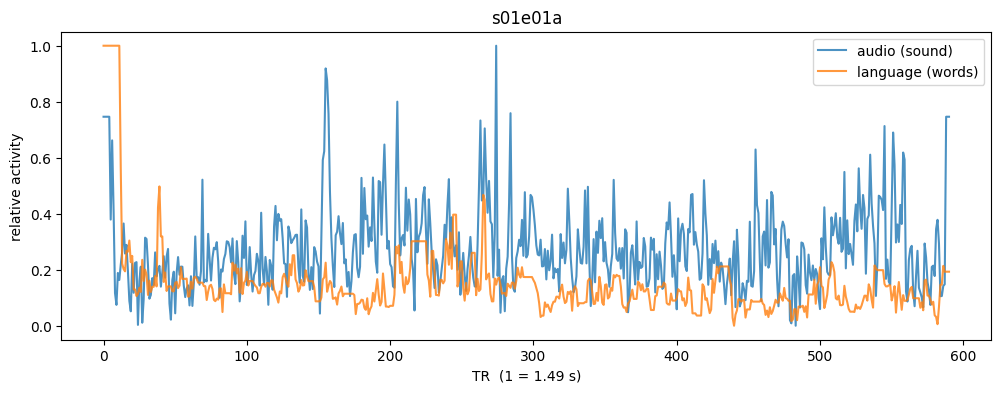

In [ ]:
import matplotlib.pyplot as plt

e = 's01e01a'
A = np.asarray(mods['audio'][e])       # audio features for this episode
L = np.asarray(mods['language'][e])    # language features for this episode

a_energy = np.linalg.norm(A, axis=1)   # collapse the 20 audio numbers → one "loudness" per TR
l_energy = np.linalg.norm(L, axis=1)   # collapse the 250 language numbers → one "how many words" per TR

a = (a_energy - a_energy.min()) / (a_energy.max() - a_energy.min())   # rescale to 0..1
l = (l_energy - l_energy.min()) / (l_energy.max() - l_energy.min())   # rescale to 0..1

plt.figure(figsize=(12,4))
plt.plot(a, label='audio (sound)',    alpha=.8)
plt.plot(l, label='language (words)', alpha=.8)
plt.xlabel('TR  (1 = 1.49 s)'); plt.ylabel('relative activity')
plt.legend(); plt.title(e); plt.show()

🔼
The headline pattern: blue (audio) rides higher and is almost continuous — it's rarely near zero — while orange (language) sits lower and comes in bursts. That's the whole point made visible. There's *almost always some sound* in a sitcom (room tone, music, the laugh track, footsteps), so audio never really goes quiet. Words, on the other hand, come and go — people talk, then pause, then a laugh beat, then talk again. So audio = a high, busy baseline; language = intermittent spikes on top of a low floor.

Now look at the relationship between the two lines:

- **Blue spikes with no orange spike** (e.g. the tall blue peaks around TR 155, 205, 275) = sound with no words — music stings, the laugh track, sound effects. That's the gap your project cares about.
- **Orange rises and blue rises with it** (lots of the middle section) = people talking, which of course also makes sound. That overlap is real, and it's precisely the confound your time-scrambled control exists to break.
- **Orange near zero while blue stays up** (e.g. the dip around TR 480–500) = a stretch with sound but little dialogue.

Two things to be skeptical about, because reading your own plots critically is the skill here:

The peaks that hit exactly **1.0** (orange near the start, blue around TR 275) aren't special — your min-max rescaling *forces* the single largest value in each line to 1.0 by construction. So "it touches 1.0" just means "loudest moment of the episode," nothing more.

That **big isolated spike in the first ~10 TRs** (orange shooting to 1.0 before audio even settles) is worth a second look. A lone spike right at the very edge is often an artifact — an alignment or normalization edge effect — rather than real content. Not a crisis, just something to eyeball before you trust the first few TRs.

For your project, this plot is reassuring: language is a genuinely *sparser, distinct* signal, not a copy of audio. That means adding language features gives the model real new information to work with — and the places where the two lines move together are exactly why you need the scrambled control.

In [ ]:
e = 's01e01a'
a = np.linalg.norm(np.asarray(mods['audio'][e]),    axis=1)   # audio activity per TR
l = np.linalg.norm(np.asarray(mods['language'][e]), axis=1)   # language activity per TR

# 1. If they were the same thing, they'd track each other. How much do they?
print('correlation audio vs language:', np.corrcoef(a, l)[0,1].round(2))

# 2. Take the moments language calls "quietest" (no words), and see what audio is doing there
quiet_words = l < np.percentile(l, 10)          # the 10% least-wordy TRs
print('in those no-word moments — audio is at',
      (a[quiet_words].mean() / a.mean() * 100).round(0), '% of its usual level')

correlation audio vs language: 0.21
in those no-word moments — audio is at 97.0 % of its usual level


🔼
* "correlation audio vs language: 0.21
in those no-word moments — audio is at 97.0 % of its usual level"
* Correlation = 0.21. This is the "are audio and language secretly the same signal?" test. If they were duplicates, it'd be near 1.0. If they were totally unrelated, near 0. You got 0.21 — low, but not zero. That's the sweet spot: they overlap a little (because people talking also makes sound, so the two rise together during dialogue), but they're mostly carrying different information. Audio is not just a copy of language, and language is not just a copy of audio. Good — that's the premise your whole project needs.
* Audio at 97% in the no-word moments. This is the killer one. You took the 10% of TRs where language is quietest — basically the moments with no dialogue — and asked "what's audio doing here?" Answer: still running at 97% of its normal level. So when the words switch off, sound barely dips. That's the laugh track, the music, the room noise carrying on without anyone speaking. This is the concrete proof of the thing you were unsure about: audio really does contain all that non-speech stuff, and it's independent of whether words are present.

* Put the two together and here's the sentence you've earned: audio and language are largely distinct streams (r = 0.21), and audio stays almost fully active even when no one is talking (97%), because it captures music, laughter, and ambience — not just speech.

* Why this matters for the actual project, not just for understanding the data: this is the empirical backing for your scrambled-language control. Your design worries that adding language features might help just because they're extra numbers correlated with sound. These results show language genuinely isn't redundant with audio — so if the full model beats baseline in language parcels and beats the scrambled control, you can argue the gain is real linguistic information, not audio riding along. You could even drop these two numbers straight into your methods or a supplementary "feature sanity check."


In [ ]:
L = np.asarray(mods['language']['s01e01a'])
print(L.dtype, L.shape)      # float..., (591, 250)  → numeric, not strings
print(L[0][:5])              # first 5 numbers of the first TR

float32 (591, 250)
[125.528496  77.98031   29.119946  12.187164 -28.082039]


🔼 confirms the language features are numbers. float32 (591, 250) = 591 TRs, 250 numbers each, and they're floats — not text. The first TR's first five values are [125.5, 78.0, 29.1, 12.2, -28.1]. That's your proof: the language feature file holds numbers, not the dry words. Settled.

In [ ]:
import pandas as pd
tr = pd.read_csv(f'{ROOT}/stimuli/transcripts/friends/s1/friends_s01e01a.tsv', sep='\t')
print(tr.columns.tolist()); print(tr.head())

['text_per_tr', 'words_per_tr', 'onsets_per_tr', 'durations_per_tr']
  text_per_tr words_per_tr onsets_per_tr durations_per_tr
0         NaN           []            []               []
1         NaN           []            []               []
2         NaN           []            []               []
3         NaN           []            []               []
4         NaN           []            []               []


🔼 the transcript — the "dry words" stage — and it's telling you something useful even though it looks empty. The columns are text_per_tr, words_per_tr, onsets_per_tr, durations_per_tr. So this transcript is already organised by TR — one row per brain snapshot, and each row is meant to hold the words spoken during that TR, plus their onset times and durations. Good — that's actually a friendlier format than raw word-by-word.

In [ ]:
from nilearn import datasets
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=7)
print(len(schaefer.labels))
print(schaefer.labels[:3])

[fetch_atlas_schaefer_2018] Dataset directory found: /root/nilearn_data/schaefer_2018

1001
['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2']


In [ ]:
labels = list(schaefer.labels)[1:]   # drop the Background phantom
assert len(labels) == 1000            # everything downstream trusts this

In [ ]:
print(len(schaefer.labels))   # 1001 — the original, with Background
print(len(labels))            # 1000 — after the slice
print(labels[0])              # first real parcel now

1001
1000
7Networks_LH_Vis_1




---



### BRAIN group, Day 1, visual list


7Networks_LH_Vis_1. Split it on the underscore and you get four tokens:
* 7Networks — the atlas-version tag, identical on every parcel
* LH — hemisphere (left or right)
* Vis — the network ← this is the field you filter on
* 1 — the parcel's number inside that network

In [ ]:
visual_idx = []
for i, name in enumerate(labels):
    network = name.split('_')[2]   # '7Networks_LH_Vis_1' -> 'Vis'
    if network == 'Vis':
        visual_idx.append(i)

print(len(visual_idx))   # how many visual parcels
print(visual_idx[:5])    # the first few column numbers

162
[0, 1, 2, 3, 4]


🔼 Remember what visual_idx is: a list of column numbers. Not brain activity, not labels — just a list of positions. It's the answer to "which columns of my 1000-column brain data are visual regions?" So the list itself looks something like [0, 1, 2, 3, 4, 5, ... , 161] — a bunch of column numbers.


Now the two prints:


`len(visual_idx)` → 162.
* `len()` means "how many things are in this list." So 162 = there are 162 visual columns. Out of your 1000 brain columns, 162 of them are visual parcels. That's the count.
* And it's the number you wanted to see, because your earlier `Counter` said `Vis: 162` — so the filter found exactly as many visual parcels as the atlas says exist. Match = the filter worked.

`visual_idx[:5]` → [0, 1, 2, 3, 4]. The `[:5]` means "show me the first five items in the list." It's just a peek so you're not staring at all 162 numbers. Those five items are the first five column numbers that got tagged visual: column 0, column 1, column 2, column 3, column 4. It's saying "the visual columns start at position 0 and the next few are 1, 2, 3, 4."

In [ ]:
print(visual_idx)          # all 162 column numbers

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580]


🔼 Columns 0–80 is 81 parcels — all the left-hemisphere visual ones. Then it jumps to 500–580, another 81 — the right-hemisphere visual ones. 81 + 81 = 162.

a parcellation is a modelling choice, not ground truth. There is no true number of regions in the cortex. Other well-respected atlases exist (Glasser's 360, Gordon's 333, anatomical ones like AAL) and they disagree about boundaries. Schaefer is defensible and widely used, not correct-in-some-final-sense.

In [ ]:
print(labels[417])

7Networks_LH_Default_PFC_3


it is not "the 417th parcel" in everyday counting — that would be labels[416]. Python starts at 0, so column 417 is the 418th item if you count like a human. Whenever you write a parcel number in your pre-registration doc, say "column index 417 (0-based)" rather than "parcel 417," so nobody downstream has to guess which convention you meant. Your notebook already has an example of this ambiguity — a comment reading coords[416]  # where parcel 417 physically sits. That comment is right, but only because someone was being careful.

In [ ]:
for i in range(413, 422):
    print(i, labels[i])

413 7Networks_LH_Default_Temp_21
414 7Networks_LH_Default_Temp_22
415 7Networks_LH_Default_PFC_1
416 7Networks_LH_Default_PFC_2
417 7Networks_LH_Default_PFC_3
418 7Networks_LH_Default_PFC_4
419 7Networks_LH_Default_PFC_5
420 7Networks_LH_Default_PFC_6
421 7Networks_LH_Default_PFC_7


column 414 - the end of the default temporal group which has 22 parcels.
from column 415 onwards PFC (prefrontal cortex)

"Schaefer is all resting default" — no. Resting-state is the method they used to draw the boundaries. Default is the name of one of the seven networks. Those are different things that happen to sound similar.

Resting-state = how Schaefer was built. They watched people lie in the scanner doing nothing, and grouped bits of cortex by which bits "chatter together" while idle.
Default = the name of one of the 7 networks (the Default Mode Network). It's one borough, not the whole map.

In [ ]:
'''
Counter({'Default': 212, 'SomMot': 194, 'Vis': 162, 'Cont': 129, 'DorsAttn': 122, 'SalVentAttn': 121, 'Limbic': 60})
0 7Networks_LH_Vis_1
40 7Networks_LH_Vis_41
80 7Networks_LH_Vis_81
120 7Networks_LH_SomMot_40
160 7Networks_LH_SomMot_80
200 7Networks_LH_DorsAttn_Post_29
240 7Networks_LH_SalVentAttn_ParOper_8
280 7Networks_LH_SalVentAttn_Med_12
320 7Networks_LH_Cont_Par_4
360 7Networks_LH_Cont_pCun_1
400 7Networks_LH_Default_Temp_8
440 7Networks_LH_Default_PFC_26
480 7Networks_LH_Default_pCunPCC_16
520 7Networks_RH_Vis_21
560 7Networks_RH_Vis_61
600 7Networks_RH_SomMot_20
640 7Networks_RH_SomMot_60
680 7Networks_RH_SomMot_100
720 7Networks_RH_DorsAttn_Post_37
760 7Networks_RH_SalVentAttn_TempOccPar_16
800 7Networks_RH_SalVentAttn_Med_10
840 7Networks_RH_Limbic_TempPole_16
880 7Networks_RH_Cont_PFCl_16
920 7Networks_RH_Default_Par_9
960 7Networks_RH_Default_PFCdPFCm_5
'''

"\nCounter({'Default': 212, 'SomMot': 194, 'Vis': 162, 'Cont': 129, 'DorsAttn': 122, 'SalVentAttn': 121, 'Limbic': 60})\n0 7Networks_LH_Vis_1\n40 7Networks_LH_Vis_41\n80 7Networks_LH_Vis_81\n120 7Networks_LH_SomMot_40\n160 7Networks_LH_SomMot_80\n200 7Networks_LH_DorsAttn_Post_29\n240 7Networks_LH_SalVentAttn_ParOper_8\n280 7Networks_LH_SalVentAttn_Med_12\n320 7Networks_LH_Cont_Par_4\n360 7Networks_LH_Cont_pCun_1\n400 7Networks_LH_Default_Temp_8\n440 7Networks_LH_Default_PFC_26\n480 7Networks_LH_Default_pCunPCC_16\n520 7Networks_RH_Vis_21\n560 7Networks_RH_Vis_61\n600 7Networks_RH_SomMot_20\n640 7Networks_RH_SomMot_60\n680 7Networks_RH_SomMot_100\n720 7Networks_RH_DorsAttn_Post_37\n760 7Networks_RH_SalVentAttn_TempOccPar_16\n800 7Networks_RH_SalVentAttn_Med_10\n840 7Networks_RH_Limbic_TempPole_16\n880 7Networks_RH_Cont_PFCl_16\n920 7Networks_RH_Default_Par_9\n960 7Networks_RH_Default_PFCdPFCm_5\n"

### Visual cortex
* primary visual cortex  V1/Brodmann area 17
* V2, V3, V4, V5 (MT)

VISUAL: 162 columns, Columns 0–80 is 81 parcels — all the left-hemisphere visual ones. Then it jumps to 500–580, another 81 — the right-hemisphere visual ones. 81 + 81 = 162.



---



## Auditory [ALA]
* temporal cortex Heschl’s gyrus, superior temporal gyrus)
* but during attention, control, emotion, and motor coupling it recruits nodes across somatomotor, dorsal attention, salience/ventral attention, limbic, frontoparietal control, and default‑mode networks

The auditory cortex was previously subdivided into primary (A1) and secondary (A2) projection areas and further association areas. The modern divisions of the auditory cortex are the core (which includes primary auditory cortex, A1), the belt (secondary auditory cortex, A2), and the parabelt (tertiary auditory cortex, A3). The belt is the area immediately surrounding the core; the parabelt is adjacent to the lateral side of the belt.[6]



In [ ]:
# Auditory

## Language [Rose]

For the language areas, we can use



---



## exploring participants friends fMRI data

In [ ]:
import glob

paths = sorted(glob.glob(f'{ROOT}/fmri/*/func/*task-friends*.h5'))
assert len(paths) == 4, paths
for p in paths:
    print(p)

/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-01/func/sub-01_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5
/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-02/func/sub-02_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5
/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-03/func/sub-03_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5
/content/drive/MyDrive/Neuromatch/algonauts_2025_challenge_tutorial_data/algonauts_2025.competitors/fmri/sub-05/func/sub-05_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5


In [ ]:
import h5py, re

for p in paths:
    sub = re.search(r'(sub-\d+)', p).group(1)
    with h5py.File(p, 'r') as f:
        shapes = {k: f[k].shape for k in f.keys()}
    n_ep = len(shapes)
    total_tr = sum(v[0] for v in shapes.values())
    parcels = {v[1] for v in shapes.values()}
    print(f'{sub}  {n_ep:4d} episodes  {total_tr:7d} TRs  parcels={parcels}')

sub-01   292 episodes   137913 TRs  parcels={1000}
sub-02   292 episodes   137913 TRs  parcels={1000}
sub-03   290 episodes   137018 TRs  parcels={1000}
sub-05   289 episodes   136529 TRs  parcels={1000}


🔼 parcels={1000} on all four lines — that's the one that mattered. Every episode in every subject has exactly 1000 columns, which means your labels list (1000 entries, Background dropped) lines up with the real brain data. Your legend is now validated against the thing it describes, not just against itself. That's the Brain sub-team's core dependency confirmed.

In [ ]:
import re

def ep(k):
    m = re.search(r'task-(s\d{2}e\d{2}[a-z])$', k)
    return m.group(1) if m else None

sets = {}
for p in paths:
    sub = re.search(r'(sub-\d+)', p).group(1)
    with h5py.File(p, 'r') as f:
        eps = {ep(k) for k in f.keys()}
    assert None not in eps, sub
    sets[sub] = eps

everything = set.union(*sets.values())
common = set.intersection(*sets.values())
print('episodes somewhere:', len(everything), '| in all four:', len(common))
for sub in sorted(sets):
    print(sub, len(sets[sub]), 'missing:', sorted(everything - sets[sub]))

episodes somewhere: 292 | in all four: 287
sub-01 292 missing: []
sub-02 292 missing: []
sub-03 290 missing: ['s05e20a', 's06e03a']
sub-05 289 missing: ['s04e01a', 's04e01b', 's04e13b']


In [ ]:
import h5py, numpy as np, matplotlib.pyplot as plt

p = [x for x in paths if 'sub-01' in x][0]
with h5py.File(p, 'r') as f:
    key = [k for k in f.keys() if k.endswith('s01e02a')][0]
    Y = f[key][:]

TR = 1.49
t = np.arange(Y.shape[0]) * TR / 60      # minutes
print(key, Y.shape)

ses-001_task-s01e02a (482, 1000)


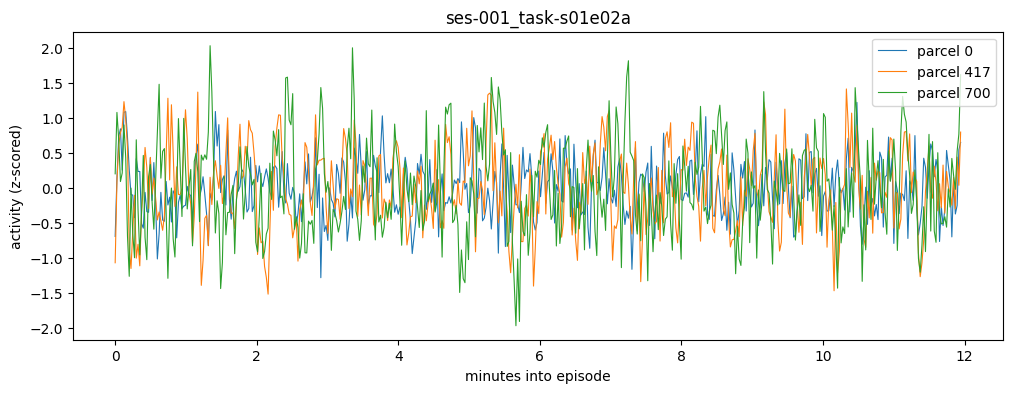

In [ ]:
plt.figure(figsize=(12, 4))
for i in [0, 417, 700]:
    plt.plot(t, Y[:, i], lw=0.8, label=f'parcel {i}')
plt.xlabel('minutes into episode'); plt.ylabel('activity (z-scored)')
plt.legend(); plt.title(key); plt.show()

# single parcel's activity

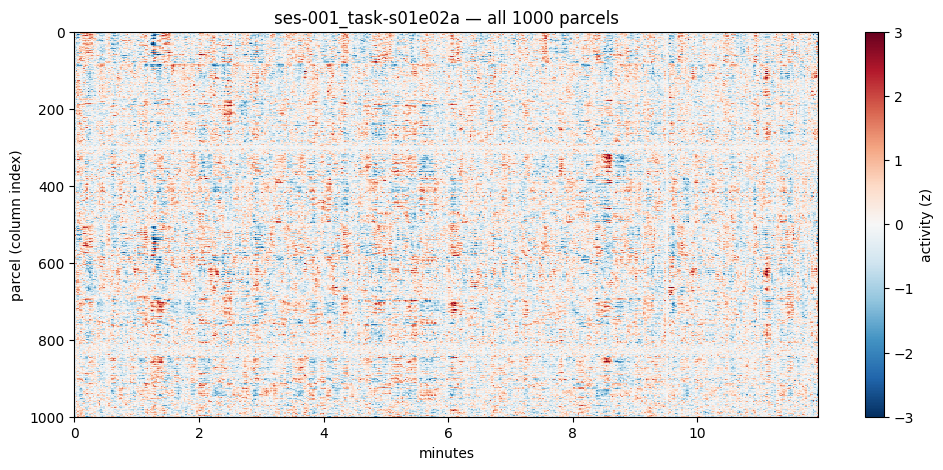

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(Y.T, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
           extent=[0, t[-1], 1000, 0], interpolation='nearest')
plt.colorbar(label='activity (z)')
plt.xlabel('minutes'); plt.ylabel('parcel (column index)')
plt.title(f'{key} — all 1000 parcels'); plt.show()

# the whole brain activity

red = above average activity
blue = below average

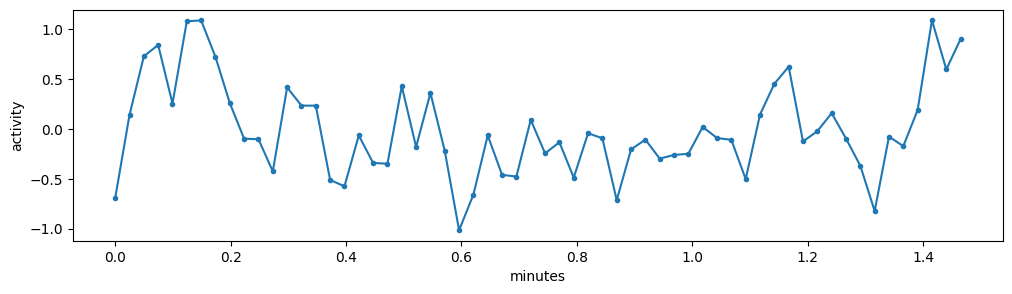

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(t[:60], Y[:60, 0], marker='o', ms=3)
plt.xlabel('minutes'); plt.ylabel('activity'); plt.show()